In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df = pd.read_excel('synthetic_data_transformation_practice.xlsx')
df.head()

,record_id,age_years,height_cm,study_hours_week,sleep_hours_day,attendance_rate_pct,exam_score,monthly_income_pln,distance_to_campus_km,website_visits_month,purchase_count_month,purchase_amount_pln,education_level,satisfaction_level,risk_level,city,employment_status,program,preferred_device,uses_mobile_app
0,TRN-0001,36,172.4,5.6,5.4,77.5,67.1,10618,0.89,38,2,82.61,Bachelor,Very Low,High,Warsaw,Full-time,Software Engineering,Tablet,Yes
1,TRN-0002,30,147.2,8.9,6.0,87.6,99.9,5152,0.97,62,2,76.22,Bachelor,High,Medium,Wroclaw,Full-time,Cybersecurity,Desktop,No
2,TRN-0003,32,173.5,6.2,7.6,86.2,59.2,3686,6.12,23,3,135.76,Master,High,Low,Krakow,Full-time,Data Science,Mobile,Yes
3,TRN-0004,23,172.1,16.0,5.8,82.4,70.2,1159,1.78,38,0,0.00,High School,Medium,Medium,Gdansk,Student,Software Engineering,Mobile,Yes
4,TRN-0005,31,163.7,4.4,7.3,82.8,68.3,2619,6.71,38,3,362.42,Master,Medium,Low,Wroclaw,Student,Cybersecurity,Mobile,Yes


# Data Description


 Number of records: 1,000
 Number of columns: 20

 Dataset purpose:
 This synthetic dataset is designed for practicing:

 1. Feature scaling
 2. Standardization
 3. Min-Max normalization
 4. Logarithmic transformation
 5. Square-root transformation
 6. Box-Cox transformation
 7. Z-score calculation
 8. Ordinal encoding
 9. Label encoding
 10. One-hot encoding

 The dataset contains:

 - Numerical variables with different measurement scales
 - Approximately symmetric numerical variables
 - Right-skewed numerical variables
 - Positive-only variables
 - Variables containing zero
 - Ordinal categorical variables
 - Nominal categorical variables
 - Binary categorical variables

 The dataset has no missing values and no duplicate record IDs.
 


 
 1. record_id
 

 Data type:
     String / Identifier

 Example values:
     TRN-0001
     TRN-0002
     TRN-0003

 Description:
     A unique identifier assigned to each record in the dataset.

 Important:
     This column does not represent a measurable feature.

 Recommended treatment:
     - Do not scale it.
     - Do not normalize it.
     - Do not encode it as a model feature.
     - It can be used as the DataFrame index or dropped before modeling.


 
 2. age_years
 

 Data type:
     Numerical — discrete

 Unit:
     Years

 Description:
     The age of the individual.

 Approximate range:
     18 to 60 years

 Distribution:
     Approximately symmetric, with most values concentrated around young
     and middle-aged adults.

 Recommended transformations:
     - Standardization
     - Min-Max normalization
     - Z-score calculation

 Example:
     age_standardized = (age - mean_age) / standard_deviation_age


 
 3. height_cm
 

 Data type:
     Numerical — continuous

 Unit:
     Centimeters

 Description:
     The height of the individual in centimeters.

 Approximate range:
     145 to 198 centimeters

 Distribution:
     Approximately symmetric and close to a normal distribution.

 Recommended transformations:
     - Standardization
     - Min-Max normalization
     - Z-score calculation

 This is a useful column for demonstrating standardization because its
 values are measured on a different scale from age, income, and exam score.


 
 4. study_hours_week
 

 Data type:
     Numerical — continuous

 Unit:
     Hours per week

 Description:
     The number of hours the individual studies during a typical week.

 Approximate range:
     1 to 40 hours

 Distribution:
     Moderately right-skewed.

 Most individuals have moderate study hours, while a smaller number study
 for many hours.

 Recommended transformations:
     - Standardization
     - Min-Max normalization
     - Logarithmic transformation using log1p()
     - Square-root transformation

 log1p() may be used because it safely calculates:

     log(1 + x)


 
 5. sleep_hours_day
 

 Data type:
     Numerical — continuous

 Unit:
     Average hours per day

 Description:
     The average number of hours the individual sleeps each day.

 Approximate range:
     4.2 to 9.5 hours

 Distribution:
     Approximately symmetric and concentrated around seven hours.

 Recommended transformations:
     - Standardization
     - Min-Max normalization
     - Z-score calculation

 A logarithmic transformation is generally unnecessary because this column
 is not strongly right-skewed.


 
 6. attendance_rate_pct
 

 Data type:
     Numerical — continuous

 Unit:
     Percentage

 Description:
     The percentage of classes attended by the individual.

 Approximate range:
     40% to 100%

 Example:
     82.5 means that the individual attended approximately 82.5% of classes.

 Recommended transformations:
     - Min-Max normalization
     - Standardization

 Min-Max normalization can transform this column into the range [0, 1].

 Formula:

     x_normalized = (x - x_min) / (x_max - x_min)


 
 7. exam_score
 

 Data type:
     Numerical — continuous

 Unit:
     Score points

 Description:
     The individual's exam result.

 Approximate range:
     20 to 100

 Higher study hours and attendance generally contribute to higher exam
 scores, although random variation is also included.

 Recommended transformations:
     - Standardization
     - Min-Max normalization
     - Z-score calculation

 This column is useful for comparing standardization and normalization.


 
 8. monthly_income_pln
 

 Data type:
     Numerical — continuous and positive

 Unit:
     Polish złoty per month

 Description:
     The individual's estimated monthly income.

 Distribution:
     Strongly right-skewed.

 Most individuals have low or moderate incomes, while a small number have
 very high incomes.

 The dataset intentionally contains several high-income extreme values.

 Minimum value:
     450 PLN

 Important:
     Every value is strictly greater than zero.

 Recommended transformations:
     - Natural logarithmic transformation
     - Box-Cox transformation
     - Square-root transformation
     - Standardization after reducing the skewness

 Logarithmic example:

     income_log = np.log(monthly_income_pln)

 This column is especially suitable for studying how logarithmic and
 Box-Cox transformations reduce right skewness.


 
 9. distance_to_campus_km
 

 Data type:
     Numerical — continuous and positive

 Unit:
     Kilometers

 Description:
     The distance between the individual's residence and the campus.

 Approximate range:
     0.15 to 45 kilometers

 Distribution:
     Right-skewed.

 Many individuals live close to the campus, while a smaller number live
 much farther away.

 Important:
     Every value is strictly greater than zero.

 Recommended transformations:
     - Logarithmic transformation
     - Square-root transformation
     - Box-Cox transformation

 This is an appropriate Box-Cox practice column because Box-Cox requires
 all values to be strictly positive.


 
 10. website_visits_month
 

 Data type:
     Numerical — discrete count

 Unit:
     Number of visits per month

 Description:
     The number of times the individual visited the platform's website
     during one month.

 Distribution:
     Strongly right-skewed.

 Most individuals have a moderate number of visits, but a small number are
 extremely active users.

 Recommended transformations:
     - Logarithmic transformation using np.log1p()
     - Square-root transformation
     - Min-Max normalization
     - Standardization after reducing skewness

 Example:

     visits_log = np.log1p(website_visits_month)


 
 11. purchase_count_month
 

 Data type:
     Numerical — discrete count

 Unit:
     Number of purchases per month

 Description:
     The number of purchases made by the individual during one month.

 Important:
     This column contains zero values.

 A value of zero means that the individual did not purchase anything during
 the month.

 Distribution:
     Right-skewed count distribution.

 Recommended transformations:
     - Square-root transformation
     - Logarithmic transformation using np.log1p()

 Examples:

     purchase_count_sqrt = np.sqrt(purchase_count_month)

     purchase_count_log = np.log1p(purchase_count_month)

 Direct Box-Cox transformation cannot be applied because the column contains
 zeros. The values must first be shifted:

     purchase_count_shifted = purchase_count_month + 1


 
 12. purchase_amount_pln
 

 Data type:
     Numerical — continuous and non-negative

 Unit:
     Polish złoty per month

 Description:
     The total amount of money spent by the individual during one month.

 Important:
     This column contains zero values.

 A value of zero usually corresponds to:

     purchase_count_month == 0

 Distribution:
     Strongly right-skewed.

 Recommended transformations:
     - Logarithmic transformation using np.log1p()
     - Square-root transformation
     - Min-Max normalization

 Example:

     amount_log = np.log1p(purchase_amount_pln)

 Direct Box-Cox transformation should not be applied because Box-Cox does
 not accept zero values. The column would need to be shifted first.


 
 13. education_level
 

 Data type:
     Ordinal categorical

 Description:
     The highest education level of the individual.

 Categories in their natural order:

     High School < Bachelor < Master < PhD

 Recommended encoding:
     Ordinal encoding

 Example mapping:

     education_mapping = {
         "High School": 0,
         "Bachelor": 1,
         "Master": 2,
         "PhD": 3
     }

 The numeric values represent the order of the categories, not an exact
 mathematical distance between education levels.


 
 14. satisfaction_level
 

 Data type:
     Ordinal categorical

 Description:
     The individual's satisfaction with the platform or learning experience.

 Categories in their natural order:

     Very Low < Low < Medium < High < Very High

 Recommended encoding:
     Ordinal encoding

 Example mapping:

     satisfaction_mapping = {
         "Very Low": 1,
         "Low": 2,
         "Medium": 3,
         "High": 4,
         "Very High": 5
     }


 
 15. risk_level
 

 Data type:
     Ordinal categorical

 Description:
     The estimated risk category associated with the individual.

 It may represent academic risk, disengagement risk, or performance risk.

 Categories in their natural order:

     Low < Medium < High

 Recommended encoding:
     Ordinal encoding

 Example mapping:

     risk_mapping = {
         "Low": 1,
         "Medium": 2,
         "High": 3
     }


 
 16. city
 

 Data type:
     Nominal categorical

 Description:
     The Polish city associated with the individual.

 Possible categories:

     Katowice
     Krakow
     Warsaw
     Wroclaw
     Gdansk

 These categories do not have a natural order.

 Recommended encoding:
     One-hot encoding

 Example generated columns:

     city_Katowice
     city_Krakow
     city_Warsaw
     city_Wroclaw
     city_Gdansk

 Ordinary label encoding is not recommended because it would create an
 artificial order between cities.


 
 17. employment_status
 

 Data type:
     Nominal categorical

 Description:
     The individual's current employment situation.

 Possible categories:

     Student
     Part-time
     Full-time
     Unemployed

 These categories do not have a natural order.

 Recommended encoding:
     One-hot encoding

 Example generated columns:

     employment_status_Student
     employment_status_Part-time
     employment_status_Full-time
     employment_status_Unemployed


 
 18. program
 

 Data type:
     Nominal categorical

 Description:
     The academic or training program selected by the individual.

 Possible categories:

     Data Science
     Cybersecurity
     Business IT
     Software Engineering

 These categories do not have a natural ranking.

 Recommended encoding:
     One-hot encoding

 Label encoding should generally not be used because numbers such as 0, 1,
 2, and 3 would create a false order between the programs.


 
 19. preferred_device
 

 Data type:
     Nominal categorical

 Description:
     The device the individual prefers to use when accessing the platform.

 Possible categories:

     Mobile
     Desktop
     Tablet

 These categories do not have a natural order.

 Recommended encoding:
     One-hot encoding

 Example generated columns:

     preferred_device_Mobile
     preferred_device_Desktop
     preferred_device_Tablet


 
 20. uses_mobile_app
 

 Data type:
     Binary categorical

 Description:
     Indicates whether the individual uses the platform's mobile application.

 Possible categories:

     Yes
     No

 Recommended encoding:
     Binary label encoding

 Example mapping:

     mobile_app_mapping = {
         "No": 0,
         "Yes": 1
     }

 Because this variable contains only two categories, label encoding does not
 create a problematic artificial order.

# Scaling

In [22]:
numericac_cols = ['age_years', 'height_cm', 'study_hours_week',
       'sleep_hours_day', 'attendance_rate_pct', 'exam_score',
       'monthly_income_pln', 'distance_to_campus_km', 'website_visits_month',
       'purchase_count_month', 'purchase_amount_pln']


### Standardization

In [23]:
df[numericac_cols].head()

,age_years,height_cm,study_hours_week,sleep_hours_day,attendance_rate_pct,exam_score,monthly_income_pln,distance_to_campus_km,website_visits_month,purchase_count_month,purchase_amount_pln
0,36,172.4,5.6,5.4,77.5,67.1,10618,0.89,38,2,82.61
1,30,147.2,8.9,6.0,87.6,99.9,5152,0.97,62,2,76.22
2,32,173.5,6.2,7.6,86.2,59.2,3686,6.12,23,3,135.76
3,23,172.1,16.0,5.8,82.4,70.2,1159,1.78,38,0,0.00
4,31,163.7,4.4,7.3,82.8,68.3,2619,6.71,38,3,362.42


In [18]:
def standardization(df):
    for col in df.columns:
        mean = df[col].mean()
        std = df[col].std(ddof=0)
        df[col] = (df[col] - mean) / std
    return df 

In [21]:
df_stand = df[numericac_cols].copy()
stand_df = standardization(df_stand)
stand_df.head()

,age_years,height_cm,study_hours_week,sleep_hours_day,attendance_rate_pct,exam_score,monthly_income_pln,distance_to_campus_km,website_visits_month,purchase_count_month,purchase_amount_pln
0,0.894326,0.246461,-0.669876,-1.777619,-0.377428,-0.678830,1.236571,-0.914915,-0.380074,0.124694,0.126570
1,0.037008,-2.538539,-0.154947,-1.077585,0.611218,2.029291,0.015582,-0.904415,-0.081195,0.124694,0.059351
2,0.322780,0.368029,-0.576252,0.789171,0.474178,-1.331091,-0.311892,-0.228484,-0.566874,0.655306,0.685671
3,-0.963197,0.213307,0.952931,-1.310930,0.102212,-0.422880,-0.876371,-0.798103,-0.380074,-0.936531,-0.742431
4,0.179894,-0.715027,-0.857123,0.439155,0.141367,-0.579753,-0.550237,-0.151047,-0.380074,0.655306,3.069978


### Normalization

In [24]:
df[numericac_cols].head()

,age_years,height_cm,study_hours_week,sleep_hours_day,attendance_rate_pct,exam_score,monthly_income_pln,distance_to_campus_km,website_visits_month,purchase_count_month,purchase_amount_pln
0,36,172.4,5.6,5.4,77.5,67.1,10618,0.89,38,2,82.61
1,30,147.2,8.9,6.0,87.6,99.9,5152,0.97,62,2,76.22
2,32,173.5,6.2,7.6,86.2,59.2,3686,6.12,23,3,135.76
3,23,172.1,16.0,5.8,82.4,70.2,1159,1.78,38,0,0.00
4,31,163.7,4.4,7.3,82.8,68.3,2619,6.71,38,3,362.42


In [25]:
def normalization(df):
    for col in df.columns:
        min = df[col].min()
        max = df[col].max()
        df[col] = (df[col] - min) / (max - min)
        
    return df 

In [26]:
df_norm = df[numericac_cols].copy()
normed_df = normalization(df_norm)
normed_df.head()

,age_years,height_cm,study_hours_week,sleep_hours_day,attendance_rate_pct,exam_score,monthly_income_pln,distance_to_campus_km,website_visits_month,purchase_count_month,purchase_amount_pln
0,0.545455,0.516981,0.070270,0.18,0.570611,0.476115,0.243966,0.016061,0.030038,0.142857,0.071556
1,0.363636,0.041509,0.159459,0.30,0.763359,0.998408,0.112817,0.017845,0.060075,0.142857,0.066021
2,0.424242,0.537736,0.086486,0.62,0.736641,0.350318,0.077643,0.132724,0.011264,0.214286,0.117594
3,0.151515,0.511321,0.351351,0.26,0.664122,0.525478,0.017011,0.035913,0.030038,0.000000,0.000000
4,0.393939,0.352830,0.037838,0.56,0.671756,0.495223,0.052042,0.145884,0.030038,0.214286,0.313925


# Transformation

In [4]:
numericac_cols = ['age_years', 'height_cm', 'study_hours_week',
       'sleep_hours_day', 'attendance_rate_pct', 'exam_score',
       'monthly_income_pln', 'distance_to_campus_km', 'website_visits_month',
       'purchase_count_month', 'purchase_amount_pln']
df[numericac_cols].head()

,age_years,height_cm,study_hours_week,sleep_hours_day,attendance_rate_pct,exam_score,monthly_income_pln,distance_to_campus_km,website_visits_month,purchase_count_month,purchase_amount_pln
0,36,172.4,5.6,5.4,77.5,67.1,10618,0.89,38,2,82.61
1,30,147.2,8.9,6.0,87.6,99.9,5152,0.97,62,2,76.22
2,32,173.5,6.2,7.6,86.2,59.2,3686,6.12,23,3,135.76
3,23,172.1,16.0,5.8,82.4,70.2,1159,1.78,38,0,0.00
4,31,163.7,4.4,7.3,82.8,68.3,2619,6.71,38,3,362.42


## Logarithmic Transformation

In [45]:
logarithmic_df = df[numericac_cols].copy()

#### **age_years**

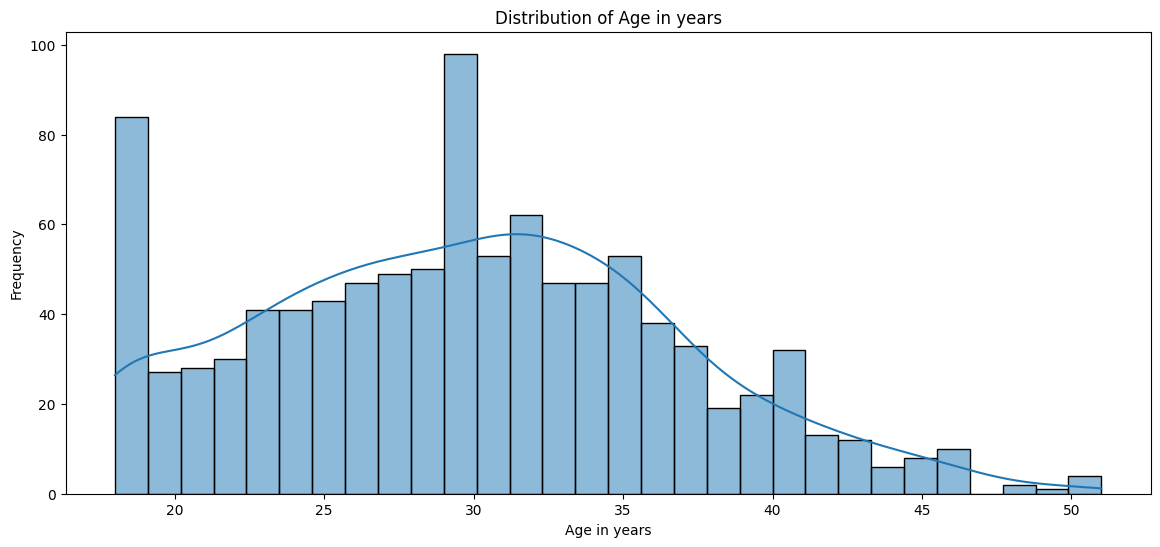

In [46]:
plt.figure(figsize=(14, 6))
sns.histplot(
    x=logarithmic_df['age_years'],
    bins=30,
    kde=True
)
plt.title("Distribution of Age in years")
plt.xlabel("Age in years")
plt.ylabel("Frequency")
plt.show()

In [47]:
logarithmic_df['age_years'].skew()

np.float64(0.2356462626383564)

age_year feature has positive skewness value 0.235, it is approximately symmetric, not required to apply Logarithmic transformation

#### **monthly_income_pln**

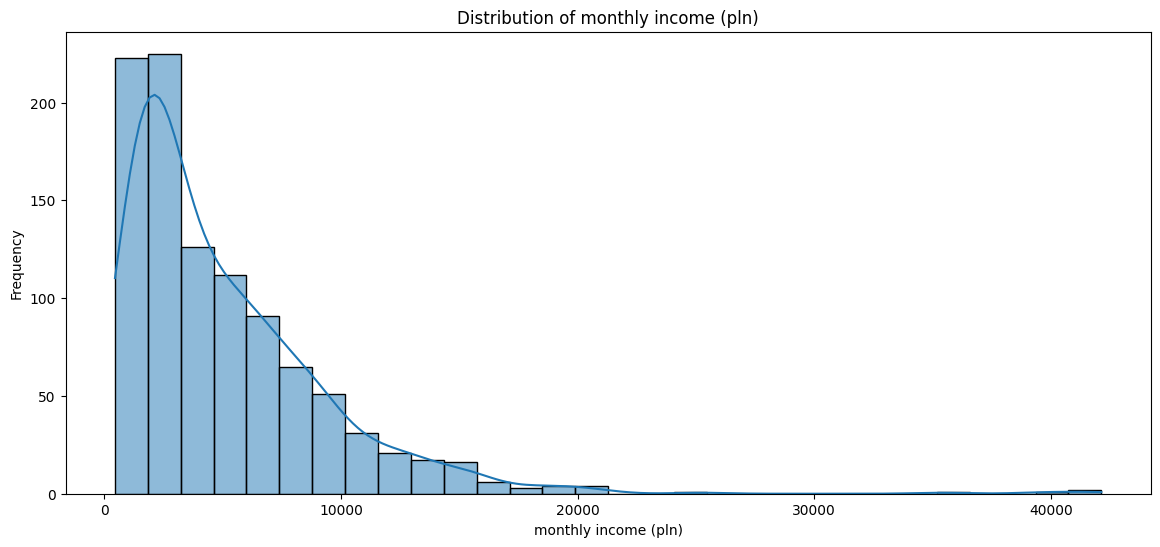

In [48]:
plt.figure(figsize=(14, 6))
sns.histplot(
    x=logarithmic_df['monthly_income_pln'],
    bins=30,
    kde=True
)
plt.title("Distribution of monthly income (pln)")
plt.xlabel("monthly income (pln)")
plt.ylabel("Frequency")
plt.show()

In [49]:
logarithmic_df['monthly_income_pln'].skew()

np.float64(2.7241405075111937)

monthly income(pln) feature has storng positive skewness, value s 2.72 so we can apply `Logarithmic Transformation`. I can apply one of them (np.log(), np.log10() and np.log2()) , not np.log1p() because monthly income feature doesn't contain any 0 value

In [53]:
log_transformed_df = df[numericac_cols].copy()
log_transformed_df['monthly_income_pln'] = np.log(logarithmic_df['monthly_income_pln'])

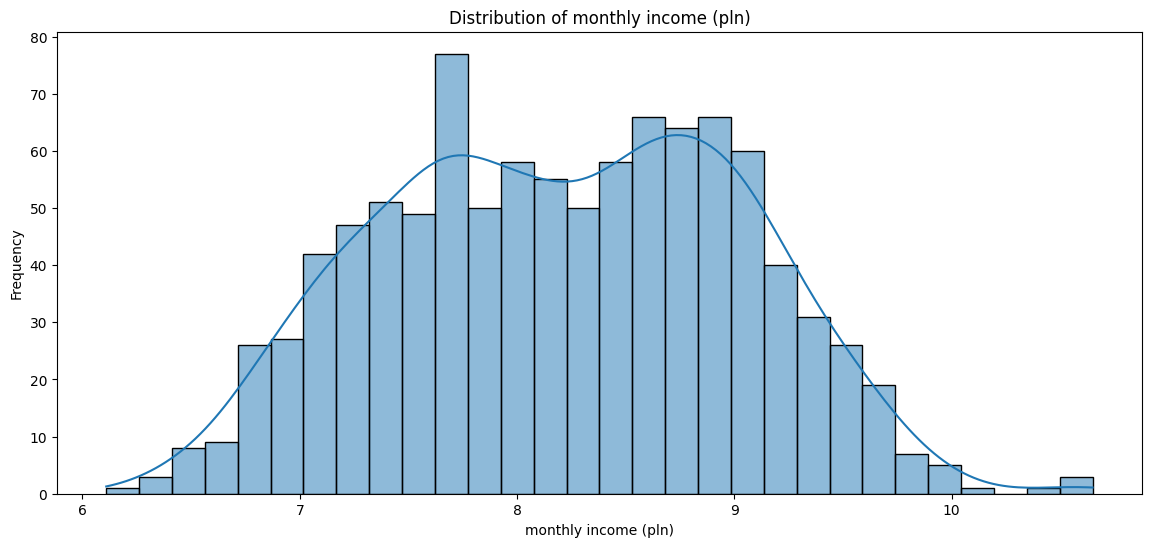

In [58]:
plt.figure(figsize=(14, 6))
sns.histplot(
    x=log_transformed_df['monthly_income_pln'],
    bins=30,
    kde=True
)
plt.title("Distribution of monthly income (pln)")
plt.xlabel("monthly income (pln)")
plt.ylabel("Frequency")
plt.show()

In [56]:
log_transformed_df['monthly_income_pln'].skew()

np.float64(0.004854758477951129)

#### **purchase_amount_pln**

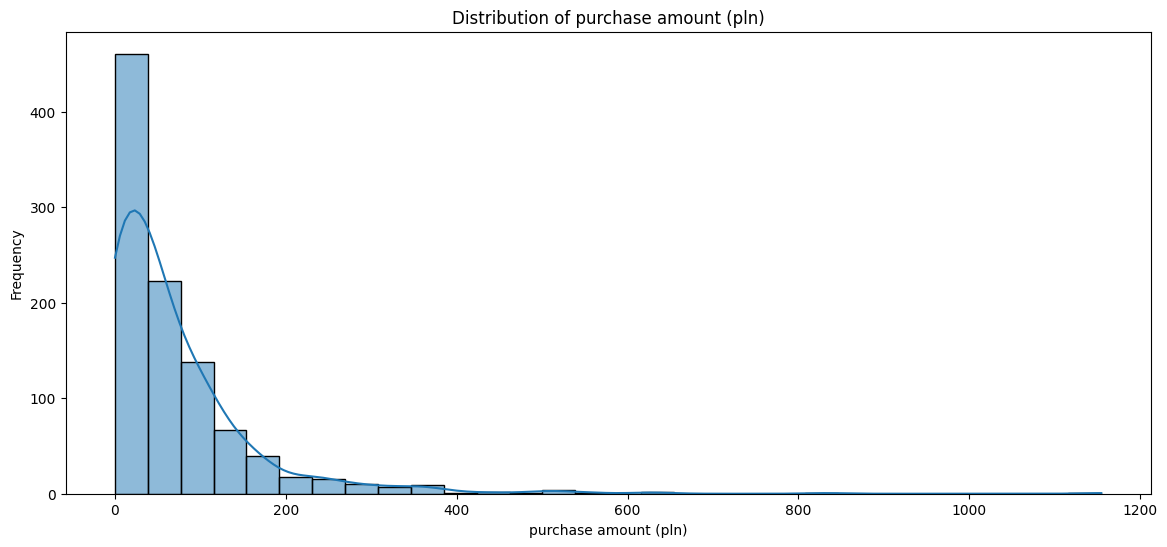

In [59]:
plt.figure(figsize=(14, 6))
sns.histplot(
    x=logarithmic_df['purchase_amount_pln'],
    bins=30,
    kde=True
)
plt.title("Distribution of purchase amount (pln)")
plt.xlabel("purchase amount (pln)")
plt.ylabel("Frequency")
plt.show()

In [60]:
df['purchase_amount_pln'].skew()

np.float64(3.8413932841607084)

In [61]:
len(df[df['purchase_amount_pln']==0])

233

the `purchase_amount_pln` feature has strong positive skewness with skewness value of 3.84, the histogram also shows a long right tail caused by a small number of high purchase amount. I can aplly Logarithmic transformation with np.log1p() approach , because feature contains 233 `0` values

In [62]:
log_transformed_df['purchase_amount_pln'] = np.log1p(logarithmic_df['purchase_amount_pln'])

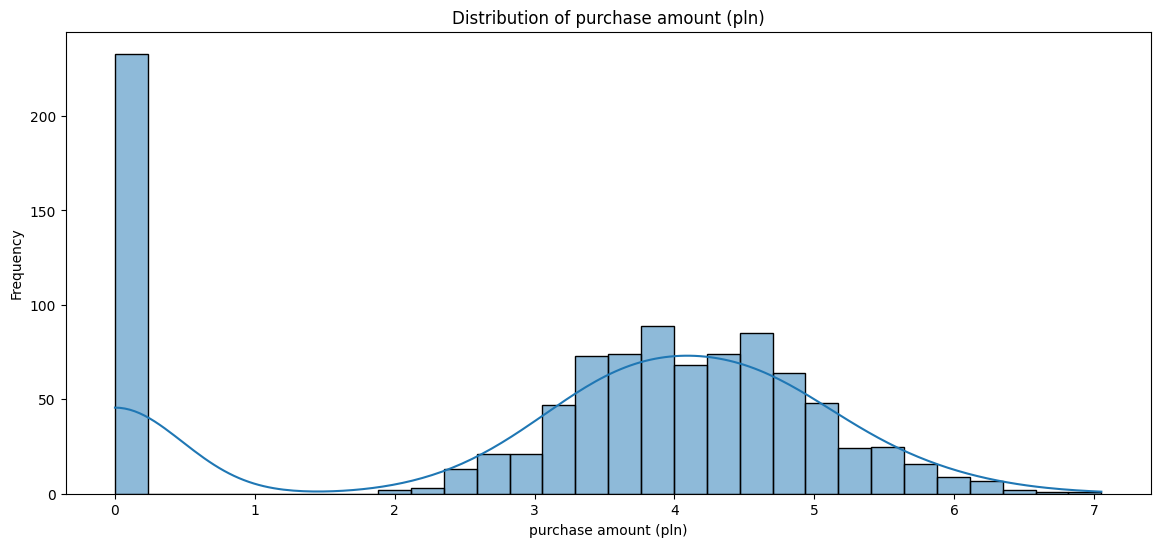

In [63]:
plt.figure(figsize=(14, 6))
sns.histplot(
    x=log_transformed_df['purchase_amount_pln'],
    bins=30,
    kde=True
)
plt.title("Distribution of purchase amount (pln)")
plt.xlabel("purchase amount (pln)")
plt.ylabel("Frequency")
plt.show()

In [64]:
log_transformed_df['purchase_amount_pln'].skew()

np.float64(-0.7629209555939135)

## Square root Transformation

In [70]:
square_trans_df = df[numericac_cols].copy()

### **website_visits_month**

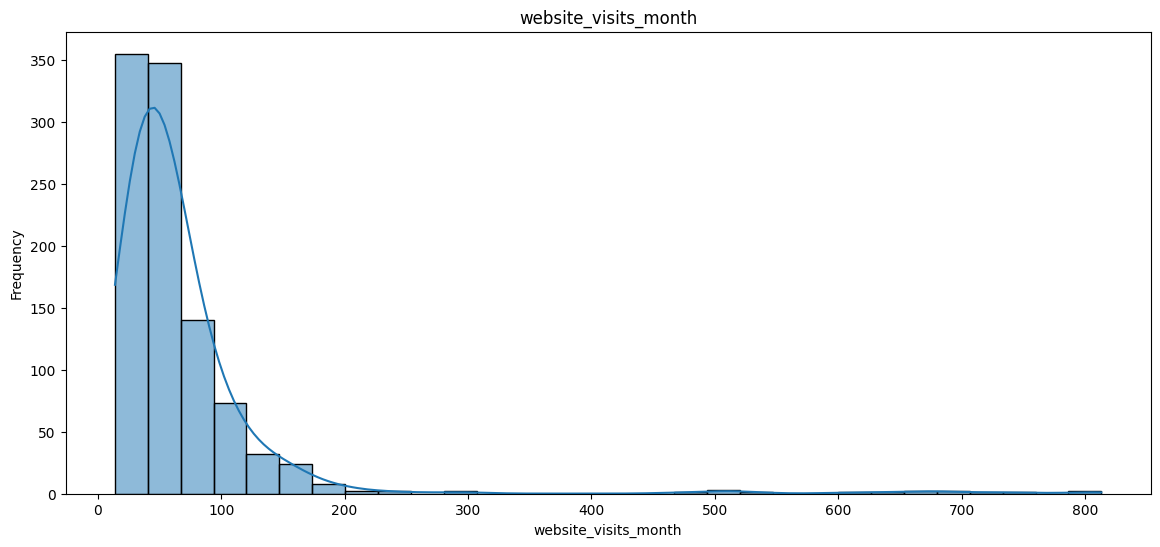

In [72]:
plt.figure(figsize=(14, 6))
sns.histplot(
    x=logarithmic_df['website_visits_month'],
    bins=30,
    kde=True
)
plt.title("website_visits_month")
plt.xlabel("website_visits_month")
plt.ylabel("Frequency")
plt.show()

In [68]:
df['website_visits_month'].skew()

np.float64(5.996849990761285)

In [69]:
df[df['website_visits_month'] == 0]

,record_id,age_years,height_cm,study_hours_week,sleep_hours_day,attendance_rate_pct,exam_score,monthly_income_pln,distance_to_campus_km,website_visits_month,purchase_count_month,purchase_amount_pln,education_level,satisfaction_level,risk_level,city,employment_status,program,preferred_device,uses_mobile_app


`website_visits_month` feature has strong positive (right) skewness, the skewness value is approximintley 6. no values equal to 0. 

In [71]:
square_trans_df['website_visits_month'] = np.sqrt(df['website_visits_month'])


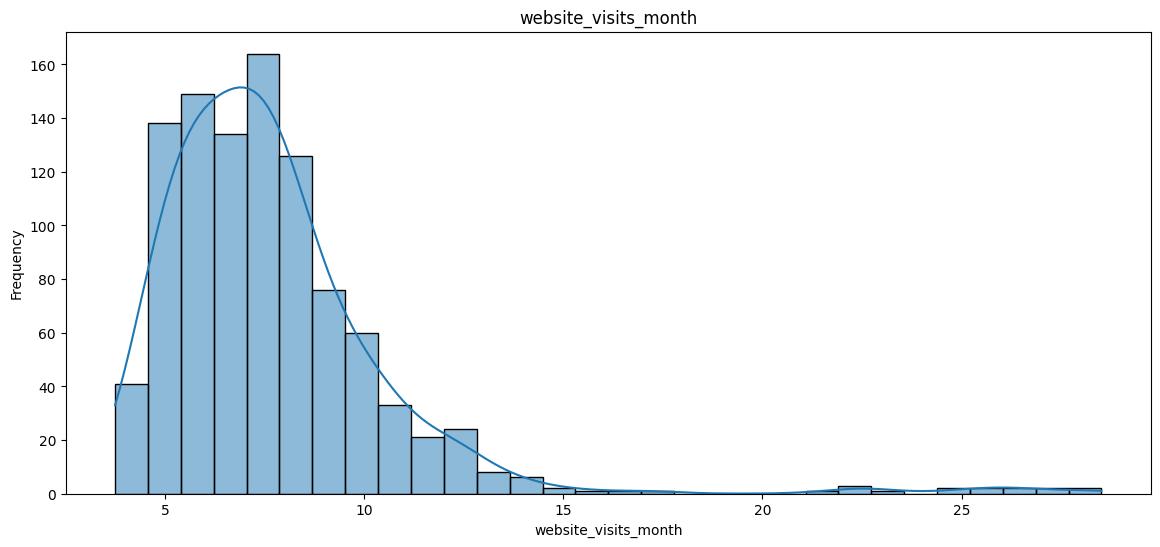

In [73]:
plt.figure(figsize=(14, 6))
sns.histplot(
    x=square_trans_df['website_visits_month'],
    bins=30,
    kde=True
)
plt.title("website_visits_month")
plt.xlabel("website_visits_month")
plt.ylabel("Frequency")
plt.show()

In [74]:
square_trans_df['website_visits_month'].skew()

np.float64(3.1338042145471507)

## Box-Cox

#### **exam_score** 

In [5]:
box_transformation = df[numericac_cols].copy()

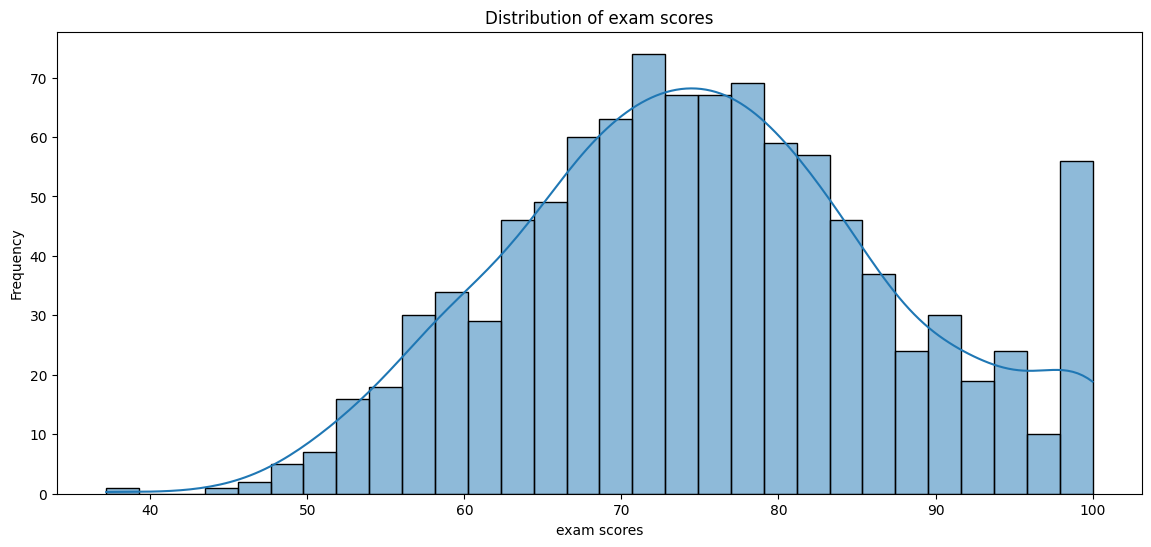

In [6]:
plt.figure(figsize=(14, 6))
sns.histplot(
    x=df['exam_score'],
    bins=30,
    kde=True
)
plt.title("Distribution of exam scores")
plt.xlabel("exam scores")
plt.ylabel("Frequency")
plt.show()

In [7]:
df['exam_score'].skew()

np.float64(0.13443670622761938)

here exam_score distribution is approximately symmetric and doesn't need tranformation for skewness, but since all values are strictly positive, we can apply `Box-Cox` transformation

In [9]:
from scipy.stats import boxcox

# applying Box-Cox transformation
transformed_values, lambda_value = boxcox(
    df['exam_score']
)
# saving transformed values
box_transformation['exam_score'] = transformed_values
print(lambda_value)

0.635540605742591


lambda value is `0.636`, so Square-root transformation

In [10]:
box_transformation['exam_score'].skew()

np.float64(-0.011215866537029665)

transformed exam-score skewness is extremly close to zero. Box-Cox made the `exam_score` slighly more symmetric.

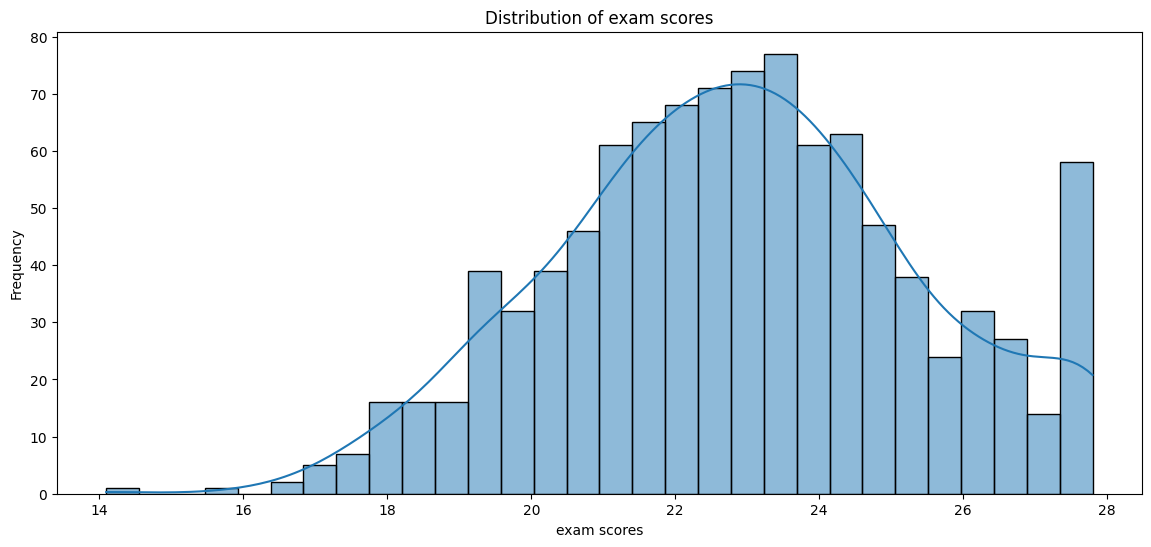

In [11]:
plt.figure(figsize=(14, 6))
sns.histplot(
    x=box_transformation['exam_score'],
    bins=30,
    kde=True
)
plt.title("Distribution of exam scores")
plt.xlabel("exam scores")
plt.ylabel("Frequency")
plt.show()

# Encoding Categorical Variables

In [49]:
categorical_columns = [
    'education_level', 
    'satisfaction_level', 
    'risk_level', 
    'city', 
    'employment_status',
    'program', 
    'preferred_device', 
    'uses_mobile_app']
encoding_df = df[categorical_columns].copy()
encoding_df.head()

,education_level,satisfaction_level,risk_level,city,employment_status,program,preferred_device,uses_mobile_app
0,Bachelor,Very Low,High,Warsaw,Full-time,Software Engineering,Tablet,Yes
1,Bachelor,High,Medium,Wroclaw,Full-time,Cybersecurity,Desktop,No
2,Master,High,Low,Krakow,Full-time,Data Science,Mobile,Yes
3,High School,Medium,Medium,Gdansk,Student,Software Engineering,Mobile,Yes
4,Master,Medium,Low,Wroclaw,Student,Cybersecurity,Mobile,Yes


## Ordinal Encoding

by intuion we can see we can apply **Ordinal Encoding** for the following feaures
- **education_level**
- **satisfaction_level** 
- **risk_level**

### education_level

In [50]:
df['education_level'].value_counts()

education_level
Bachelor       535
Master         228
High School    176
PhD             61
Name: count, dtype: int64

In [51]:
education_mapping = {
    "High School":1,
    "Bachelor":2,
    "Master":3,
    "PhD":4
}

encoding_df['education_level'] = encoding_df['education_level'].map(education_mapping)

In [52]:
encoding_df['education_level'].value_counts()

education_level
2    535
3    228
1    176
4     61
Name: count, dtype: int64

### satisfaction_level

In [53]:
encoding_df['satisfaction_level'].value_counts()

satisfaction_level
Medium       399
High         294
Low          168
Very High    111
Very Low      28
Name: count, dtype: int64

In [54]:
statisfaction_mapping = {
    "Very Low":1,
    "Low":2,
    "Medium":3,
    "High":4,
    "Very High":5
}
encoding_df['satisfaction_level'] = encoding_df['satisfaction_level'].map(statisfaction_mapping)


In [55]:
encoding_df['satisfaction_level'].value_counts()

satisfaction_level
3    399
4    294
2    168
5    111
1     28
Name: count, dtype: int64

### risk_level

In [57]:
df['risk_level'].value_counts()

risk_level
Low       442
Medium    414
High      144
Name: count, dtype: int64

In [58]:
risk_level_mapping = {
    "Low":1,
    "Medium":2,
    "High":3
}
encoding_df['risk_level'] = encoding_df['risk_level'].map(risk_level_mapping)

In [59]:
encoding_df.head()

,education_level,satisfaction_level,risk_level,city,employment_status,program,preferred_device,uses_mobile_app
0,2,1,3,Warsaw,Full-time,Software Engineering,Tablet,Yes
1,2,4,2,Wroclaw,Full-time,Cybersecurity,Desktop,No
2,3,4,1,Krakow,Full-time,Data Science,Mobile,Yes
3,1,3,2,Gdansk,Student,Software Engineering,Mobile,Yes
4,3,3,1,Wroclaw,Student,Cybersecurity,Mobile,Yes


## Nominal Encoding 

Nominal categorical columns
- **city**
- **employment_status**
- **program**
- **preferred_device**
- **uses_mobile_app**

### One-Hot Encoding

In [60]:
multi_nominal_columns = [
    "city",
    "employment_status",
    "program",
    "preferred_device"
]

one_hot_encoed_df = pd.get_dummies(
    encoding_df,
    columns=multi_nominal_columns,
    dtype=int
)

In [45]:
one_hot_encoed_df.head()

,education_level,satisfaction_level,risk_level,uses_mobile_app,city_Gdansk,city_Katowice,city_Krakow,city_Warsaw,city_Wroclaw,employment_status_Full-time,employment_status_Part-time,employment_status_Student,employment_status_Unemployed,program_Business IT,program_Cybersecurity,program_Data Science,program_Software Engineering,preferred_device_Desktop,preferred_device_Mobile,preferred_device_Tablet
0,Bachelor,Very Low,High,Yes,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,1
1,Bachelor,High,Medium,No,0,0,0,0,1,1,0,0,0,0,1,0,0,1,0,0
2,Master,High,Low,Yes,0,0,1,0,0,1,0,0,0,0,0,1,0,0,1,0
3,High School,Medium,Medium,Yes,1,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0
4,Master,Medium,Low,Yes,0,0,0,0,1,0,0,1,0,0,1,0,0,0,1,0


### Dummy Encoding

In [62]:
encoding_df.head()

,education_level,satisfaction_level,risk_level,city,employment_status,program,preferred_device,uses_mobile_app
0,2,1,3,Warsaw,Full-time,Software Engineering,Tablet,Yes
1,2,4,2,Wroclaw,Full-time,Cybersecurity,Desktop,No
2,3,4,1,Krakow,Full-time,Data Science,Mobile,Yes
3,1,3,2,Gdansk,Student,Software Engineering,Mobile,Yes
4,3,3,1,Wroclaw,Student,Cybersecurity,Mobile,Yes


In [63]:
multi_nominal_columns = [
    "city",
    "employment_status",
    "program",
    "preferred_device"
]

dummy_encoding_df = encoding_df[multi_nominal_columns].copy()
dummy_encoding_df.head()

,city,employment_status,program,preferred_device
0,Warsaw,Full-time,Software Engineering,Tablet
1,Wroclaw,Full-time,Cybersecurity,Desktop
2,Krakow,Full-time,Data Science,Mobile
3,Gdansk,Student,Software Engineering,Mobile
4,Wroclaw,Student,Cybersecurity,Mobile


In [64]:
dummy_encoding_df = pd.get_dummies(
    dummy_encoding_df,
    columns=multi_nominal_columns,
    drop_first=True,
    dtype=int
)

In [48]:
dummy_encoding_df.head()

,city_Katowice,city_Krakow,city_Warsaw,city_Wroclaw,employment_status_Part-time,employment_status_Student,employment_status_Unemployed,program_Cybersecurity,program_Data Science,program_Software Engineering,preferred_device_Mobile,preferred_device_Tablet
0,0,0,1,0,0,0,0,0,0,1,0,1
1,0,0,0,1,0,0,0,1,0,0,0,0
2,0,1,0,0,0,0,0,0,1,0,1,0
3,0,0,0,0,0,1,0,0,0,1,1,0
4,0,0,0,1,0,1,0,1,0,0,1,0


In [65]:
encoding_df = encoding_df.drop(columns=multi_nominal_columns)
encoding_df.head()

,education_level,satisfaction_level,risk_level,uses_mobile_app
0,2,1,3,Yes
1,2,4,2,No
2,3,4,1,Yes
3,1,3,2,Yes
4,3,3,1,Yes


In [66]:
encoding_df = pd.concat(
    [ encoding_df, dummy_encoding_df],
    axis=1
)

In [67]:
encoding_df.head()

,education_level,satisfaction_level,risk_level,uses_mobile_app,city_Katowice,city_Krakow,city_Warsaw,city_Wroclaw,employment_status_Part-time,employment_status_Student,employment_status_Unemployed,program_Cybersecurity,program_Data Science,program_Software Engineering,preferred_device_Mobile,preferred_device_Tablet
0,2,1,3,Yes,0,0,1,0,0,0,0,0,0,1,0,1
1,2,4,2,No,0,0,0,1,0,0,0,1,0,0,0,0
2,3,4,1,Yes,0,1,0,0,0,0,0,0,1,0,1,0
3,1,3,2,Yes,0,0,0,0,0,1,0,0,0,1,1,0
4,3,3,1,Yes,0,0,0,1,0,1,0,1,0,0,1,0


### Label Encoding

In [68]:
encoding_df['uses_mobile_app'].value_counts()

uses_mobile_app
Yes    776
No     224
Name: count, dtype: int64

In [69]:
mobile_uses_mapping = {
    "Yes":1,
    "No":0
}
encoding_df['uses_mobile_app'] = encoding_df['uses_mobile_app'].map(mobile_uses_mapping)

encoding_df.head()

,education_level,satisfaction_level,risk_level,uses_mobile_app,city_Katowice,city_Krakow,city_Warsaw,city_Wroclaw,employment_status_Part-time,employment_status_Student,employment_status_Unemployed,program_Cybersecurity,program_Data Science,program_Software Engineering,preferred_device_Mobile,preferred_device_Tablet
0,2,1,3,1,0,0,1,0,0,0,0,0,0,1,0,1
1,2,4,2,0,0,0,0,1,0,0,0,1,0,0,0,0
2,3,4,1,1,0,1,0,0,0,0,0,0,1,0,1,0
3,1,3,2,1,0,0,0,0,0,1,0,0,0,1,1,0
4,3,3,1,1,0,0,0,1,0,1,0,1,0,0,1,0
